# Finetuning Foundation Models

**Finetuning** adapts a pre-trained model to your data before forecasting: the model is trained for a few steps on your time series, which can improve accuracy when your series have a different distribution or scale than the data the model was pre-trained on.

Today finetuning in TimeCopilot is available for **Chronos 2** only; we will add support for more foundation models in future releases. The API reference for the Chronos finetuning configuration is [ChronosFinetuningConfig](https://timecopilot.dev/api/models/foundation/models/#timecopilot.models.foundation.chronos.ChronosFinetuningConfig).

## Import libraries

In [1]:
import pandas as pd
from functools import partial

from timecopilot import TimeCopilotForecaster
from timecopilot.models.foundation.chronos import Chronos, ChronosFinetuningConfig
from timecopilot.models.stats import AutoARIMA
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, mape, scaled_crps


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


## Load the dataset

We use the same events pageviews dataset as in the [Chronos family](https://timecopilot.dev/examples/chronos-family/) example.

In [ ]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Chronos 2

Chronos 2 supports finetuning via **`ChronosFinetuningConfig`** (see the [API reference](https://timecopilot.dev/api/models/foundation/models/#timecopilot.models.foundation.chronos.ChronosFinetuningConfig)). You pass an instance to the `Chronos` constructor; when you call `forecast()`, the model is finetuned on the context data before predicting.

**Supported parameters:**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `finetune_steps` | int | 1000 | Number of training steps. Maps to the chronos pipeline's `num_steps`. |
| `learning_rate` | float or None | None → 1e-6 | Optimizer learning rate (chronos uses 1e-6; for LoRA, 1e-5 is recommended). |
| `batch_size` | int or None | None → 256 | Training batch size for finetuning. The `batch_size` on `Chronos` is for inference only. |
| `finetune_mode` | "full" or "lora" or None | None → "full" | Full parameter update vs. LoRA. |
| `lora_config` | object or None | None | LoRA configuration when `finetune_mode="lora"`; see the [Chronos-2 quickstart](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb) for details. |
| `save_path` | str or Path or None | None | If set, the finetuned model is saved to this directory. Use the same path as `repo_id` with `finetuning_config=None` to load and reuse it for later forecasts. |

The forecast horizon `h` you pass to `forecast(df, h, ...)` is used as `prediction_length` for the internal `fit()` call.

### Compare Chronos 2 with and without finetuning

In [ ]:
# Chronos 2 without finetuning
chronos2 = Chronos(repo_id="autogluon/chronos-2-small", alias="chronos2")
# Chronos 2 with finetuning (fewer steps for a quicker example)
chronos2_finetuned = Chronos(
    repo_id="autogluon/chronos-2-small",
    alias="chronos-2-finetuned",
    finetuning_config=ChronosFinetuningConfig(
        finetune_steps=10,
        save_path="./chronos-2-finetuned-path/", # optional, save the finetuned model
    ),
)
# Chronos 2 with LoRA finetuning
chronos2_lora = Chronos(
    repo_id="autogluon/chronos-2-small",
    alias="chronos-2-finetuned-lora",
    finetuning_config=ChronosFinetuningConfig(
        finetune_mode="lora",
        finetune_steps=10,
        learning_rate=1e-5,
        save_path="./chronos-2-finetuned-lora-path/", # optional, save the finetuned model
    ),
)
auto_arima = AutoARIMA()
models = [chronos2, chronos2_finetuned, chronos2_lora, auto_arima]
tcf = TimeCopilotForecaster(models=models)
level = [20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=12, level=level)
cv_df.head()


0it [00:00, ?it/s]`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
100%|██████████| 1/1 [00:00<00:00, 32.67it/s]
1it [00:01,  1.63s/it]
0it [00:00, ?it/s]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss


100%|██████████| 1/1 [00:00<00:00, 33.51it/s]
1it [00:08,  8.41s/it]
0it [00:00, ?it/s]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss


100%|██████████| 1/1 [00:00<00:00, 40.58it/s]
1it [00:07,  7.94s/it]
0it [00:00, ?it/s]/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resour

,unique_id,ds,cutoff,y,chronos2,chronos2-lo-20,chronos2-hi-20,chronos2-lo-40,chronos2-hi-40,chronos2-lo-60,...,chronos-2-finetuned-lora-hi-80,AutoARIMA,AutoARIMA-lo-80,AutoARIMA-lo-60,AutoARIMA-lo-40,AutoARIMA-lo-20,AutoARIMA-hi-20,AutoARIMA-hi-40,AutoARIMA-hi-60,AutoARIMA-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,1927.414551,1823.906982,2055.461182,1738.863525,2191.819824,1644.456543,...,3466.595947,2345.021484,-3894.636719,-1752.690186,-208.196136,1111.517090,3578.525635,4898.238770,6442.732910,8584.679688
1,Black Friday,2024-10-31,2024-08-31,2470,2540.248047,2212.041016,3162.801025,2054.913330,4077.916016,1920.063232,...,8912.384766,3356.209473,-3393.586182,-1076.520020,594.247681,2021.857178,4690.561523,6118.170898,7788.938965,10106.004883
2,Black Friday,2024-11-30,2024-08-31,11058,20014.011719,17925.074219,22388.916016,15283.841797,24934.029297,11903.583008,...,29221.998047,20597.349609,13847.554688,16164.620117,17835.388672,19262.998047,21931.701172,23359.312500,25030.080078,27347.144531
3,Black Friday,2024-12-31,2024-08-31,3548,4806.964844,3921.377930,6003.643555,3189.047119,7413.359375,2595.310059,...,16506.568359,4478.090332,-2271.705078,45.361053,1716.128784,3143.738281,5812.442871,7240.052246,8910.820312,11227.885742
4,Black Friday,2025-01-31,2024-08-31,1724,1883.054688,1773.106445,2013.665039,1664.928467,2160.377197,1545.758057,...,5551.708984,2228.328369,-4521.467285,-2204.401123,-533.633362,893.976074,3562.680420,4990.290039,6661.057617,8978.124023


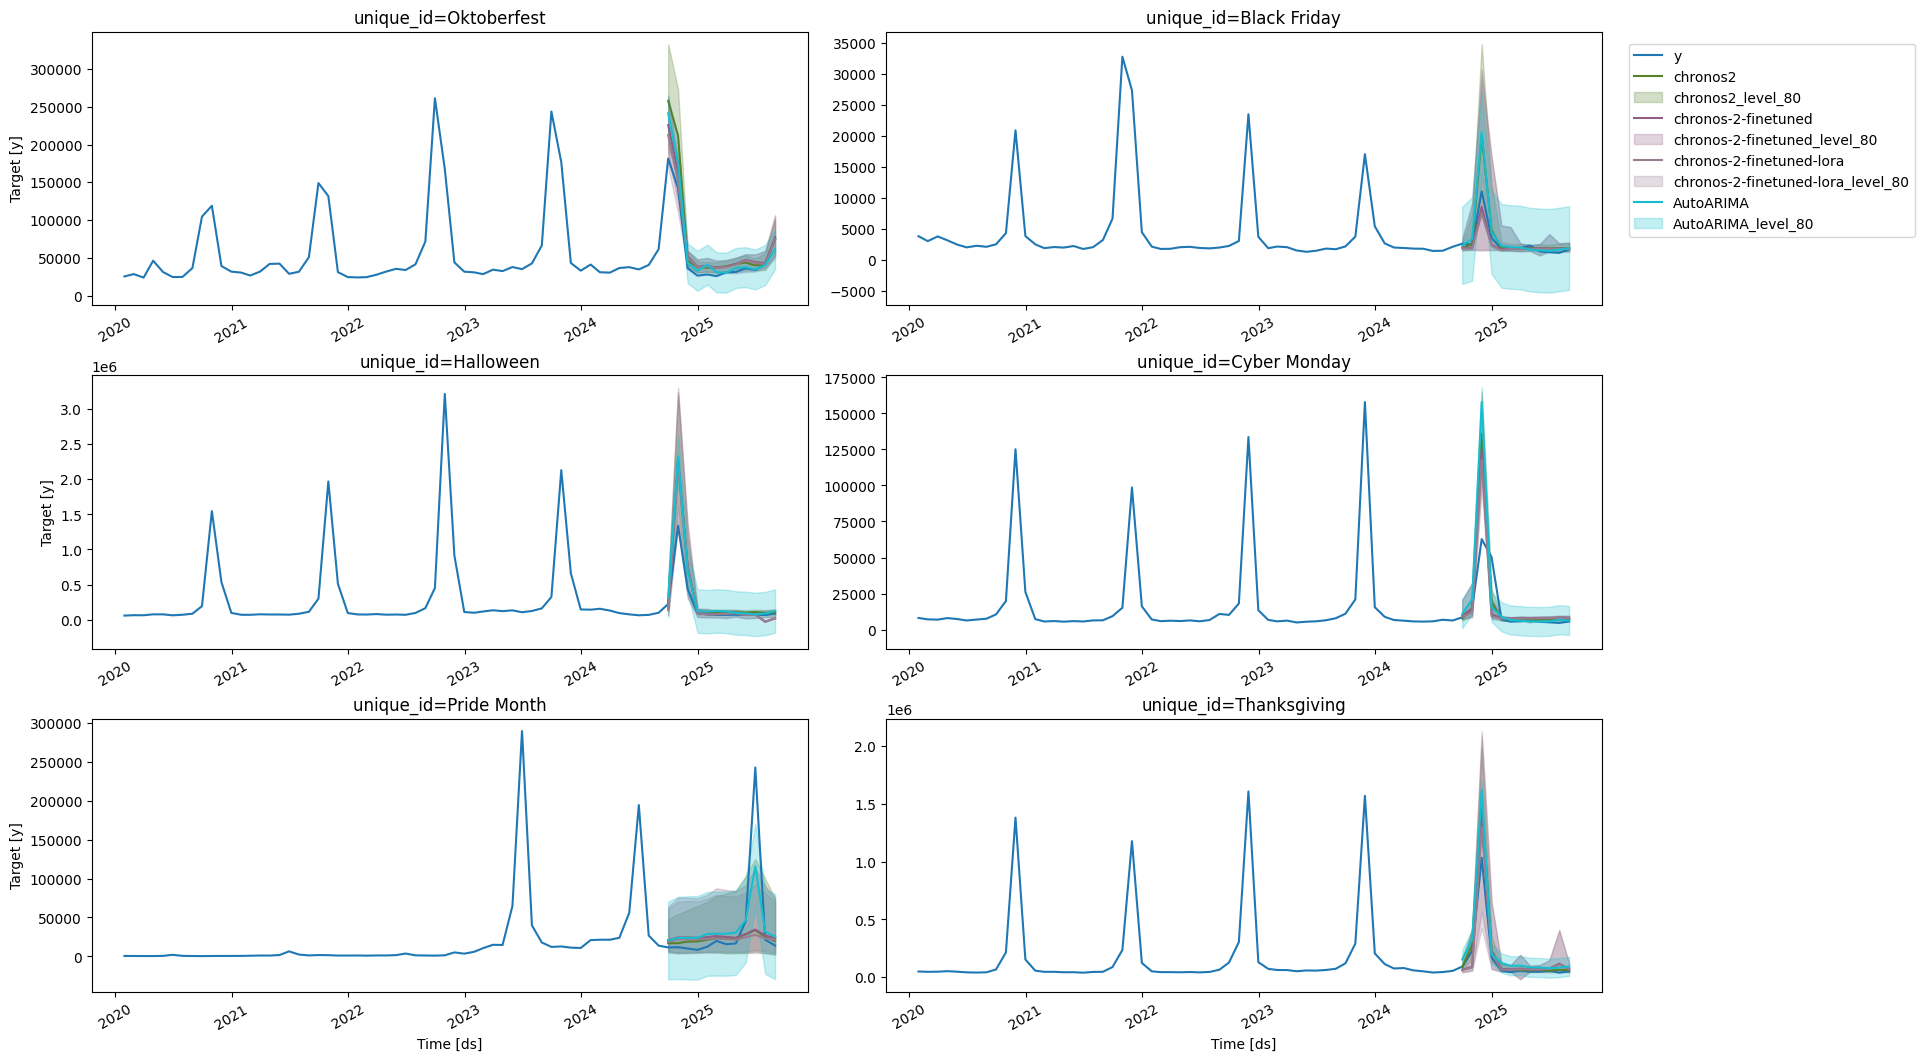

In [ ]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [ ]:
eval_compare = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_compare.groupby("metric").mean(numeric_only=True).T.sort_values(by="scaled_crps").round(3)


metric,mase,scaled_crps
chronos-2-finetuned-lora,1.509,0.364
chronos-2-finetuned,1.681,0.389
chronos2,1.705,0.412
AutoARIMA,1.897,0.565


## Using the best model for forecasts

The evaluation showed that **Chronos 2 finetuned with LoRA** had the best (lowest) scaled CRPS among the compared models. Because we saved it with `save_path="./chronos-2-finetuned-lora/"`, we can load it and use it for new forecasts without finetuning again.

In [ ]:
best_model_path = "chronos-2-finetuned-lora-path"
best_model = Chronos(
    repo_id=best_model_path,
    finetuning_config=None,
    batch_size=2,
    alias="chronos2-best",
)
fcst_best = best_model.forecast(df, h=12, freq="MS", level=[80, 90])
fcst_best.head()

100%|██████████| 3/3 [00:00<00:00, 18.56it/s]


,unique_id,ds,chronos2-best,chronos2-best-lo-80,chronos2-best-hi-80,chronos2-best-lo-90,chronos2-best-hi-90
0,Black Friday,2025-09-01,1747.354492,1240.749023,2497.809326,1049.929443,3276.111572
1,Black Friday,2025-10-01,2236.327637,1297.549805,6467.433594,1051.353516,8020.196289
2,Black Friday,2025-11-01,12611.657227,5214.403320,22868.658203,3748.068359,27442.648438
3,Black Friday,2025-12-01,3226.313232,1481.221680,8127.299805,1229.192383,10268.513672
4,Black Friday,2026-01-01,1604.315918,1096.437012,2360.342773,894.071777,3173.337891


The forecasts above come from the best-performing model in our comparison (Chronos 2 with LoRA finetuning), loaded from the saved checkpoint. You can reuse this path in other notebooks or scripts for inference without running finetuning again.

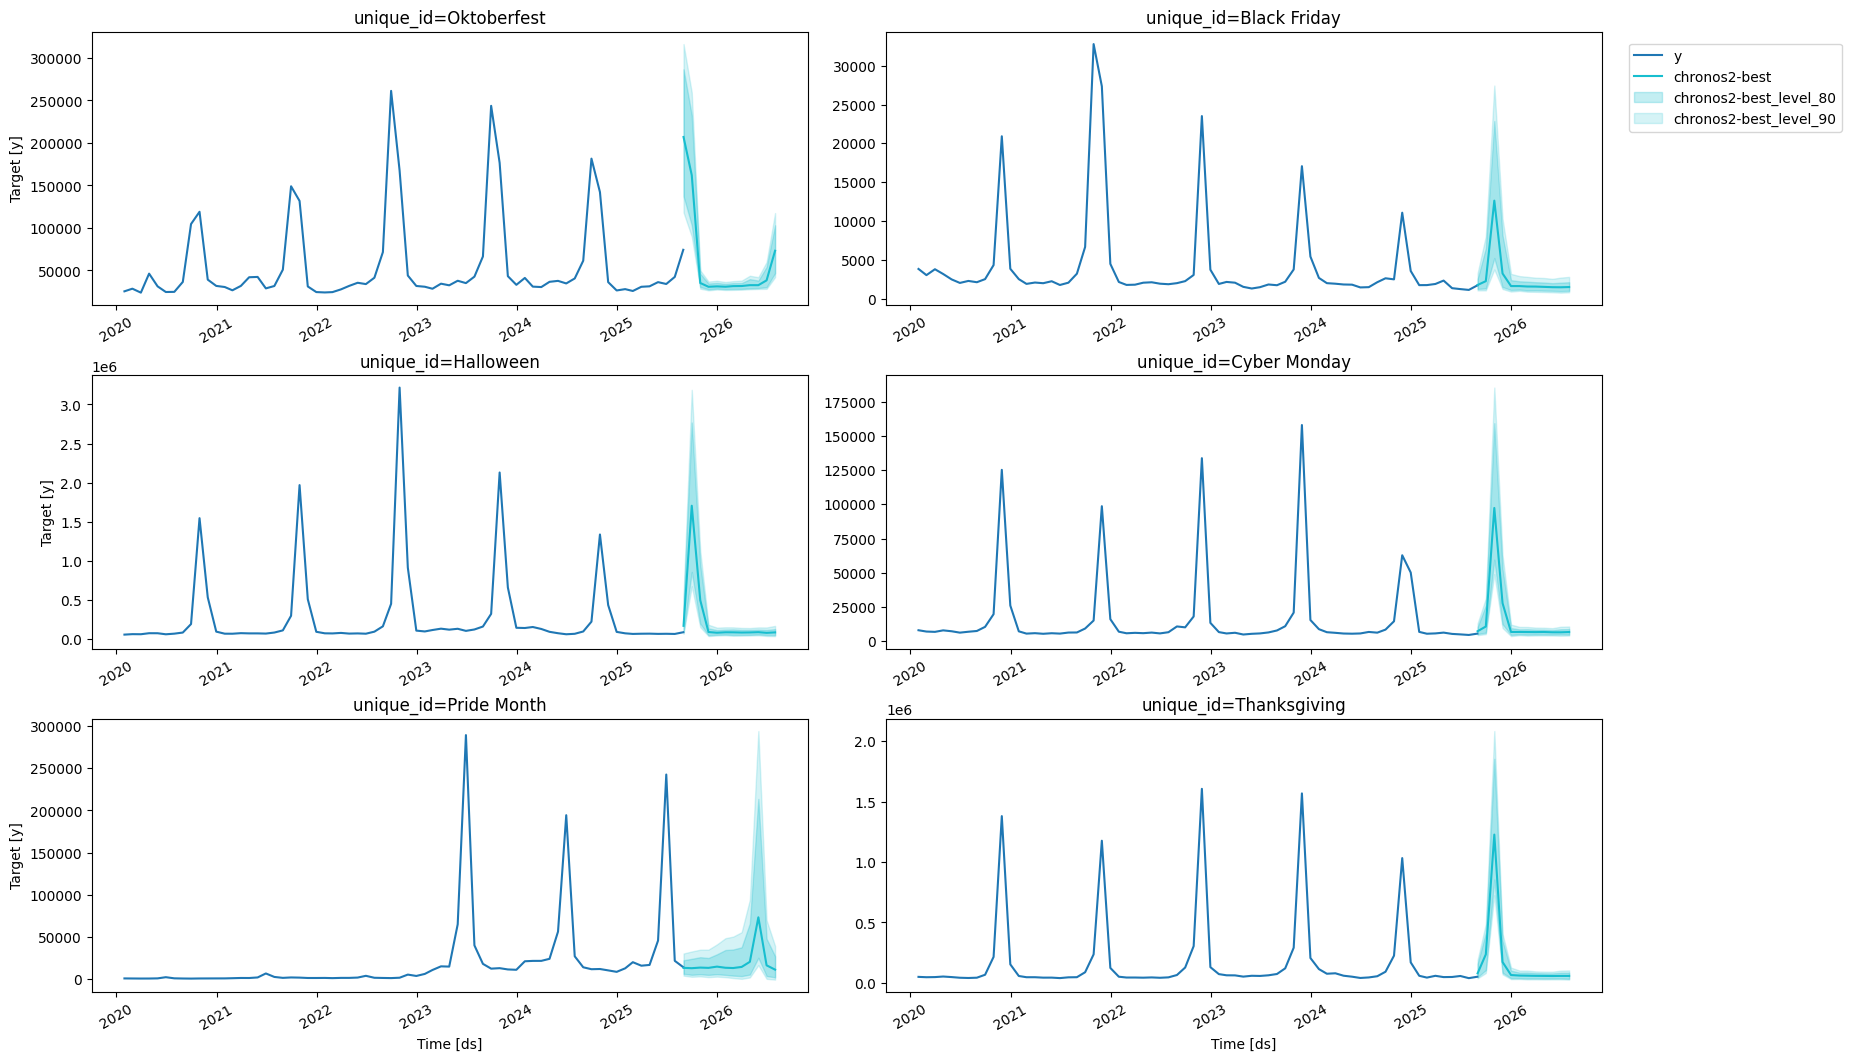

In [ ]:
best_model.plot(df, fcst_best, level=[80, 90])

## Finetuning evaluation

We compare **MAPE** across different `finetune_steps` (and a baseline with no finetuning) by running cross-validation and evaluating with MAPE. You can use the results to choose a finetuning step for production. In this example the target `y` is never zero in the evaluation period, so MAPE is well-defined; in general you should be careful with MAPE (it is undefined or unstable when `y` is zero or very small). We use it here for illustration only.

**Note:** This experiment finetunes the model **on the fly**. In every cross-validation window, the model is finetuned on the data up to the cutoff, then forecasts the next `h` steps. No pre-saved finetuned checkpoint is reused between windows, each window gets a fresh finetuning run.

**Parameters**

| Parameter | Example value | Description |
|-----------|----------------|-------------|
| `h` | 24 | Forecast horizon (number of steps to predict per window). |
| `n_windows` | 4 | Number of cross-validation windows (backtest pivots). |
| `finetune_steps` (candidates) | `range(10, 50, 10)` | Finetuning steps to compare; include baseline (no finetuning) to compare against. |
| `repo_id` | autogluon/chronos-2-small | Chronos model to use (and optionally finetune). |
| Metric | MAPE | Metric used to compare configs (here MAPE for illustration; choose one appropriate for your use case). |

In [4]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv",
    parse_dates=["date"],
).melt("date", var_name="unique_id", value_name="y")
df.rename(columns={"date": "ds"}, inplace=True)
df = df.groupby("unique_id").tail(24 * 7 * 7)

In [12]:
df.groupby("unique_id").tail(4 * 24).query("y==0")

,ds,unique_id,y


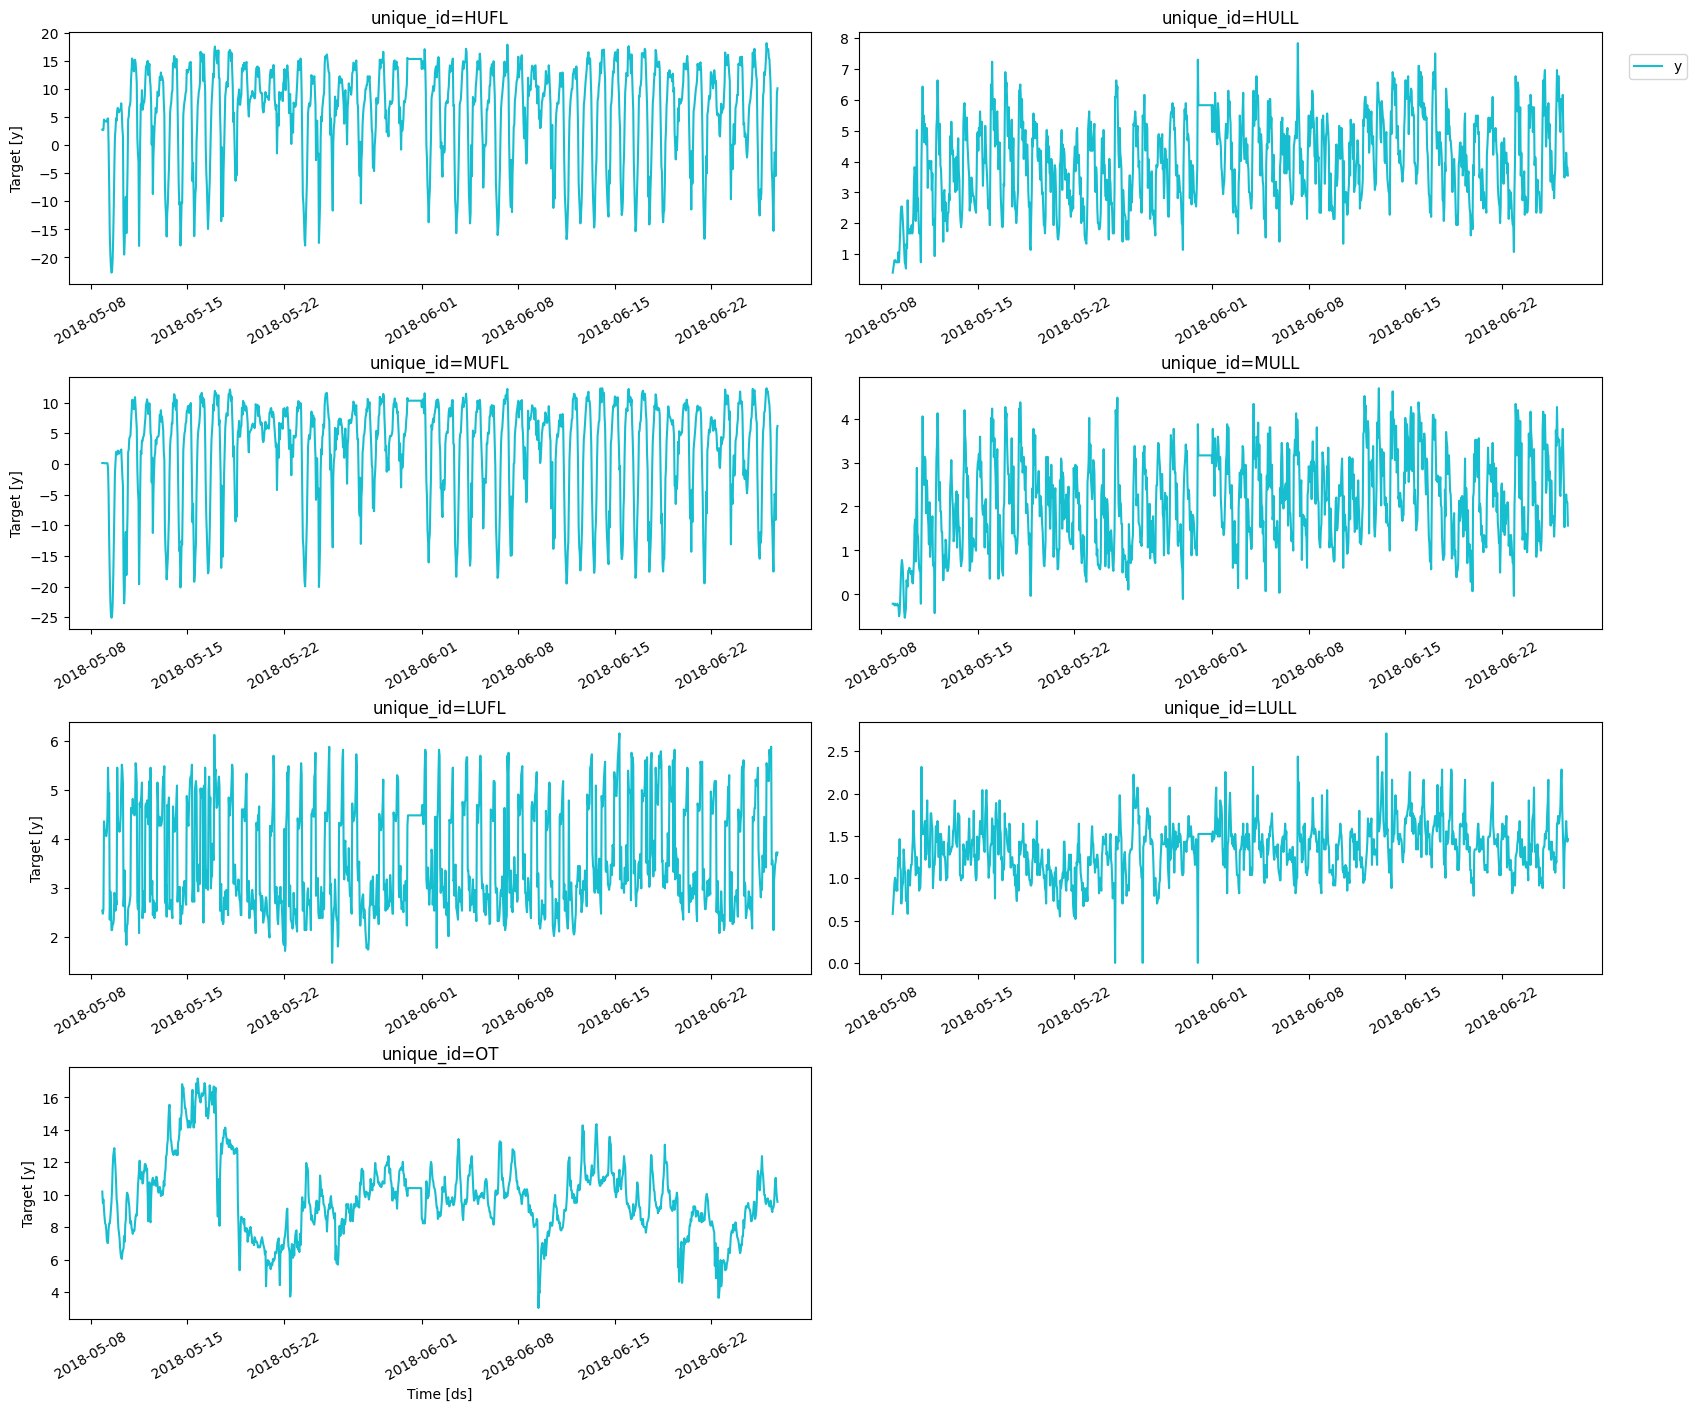

In [6]:
TimeCopilotForecaster.plot(df)

In [7]:
h = 24
n_windows = 4

# Baseline (no finetuning) + 4 finetune step values — one forecaster per config
finetune_steps_list = range(10, 50, 10)
models_eval = [
    Chronos(repo_id="autogluon/chronos-2-small", alias="Chronos2-baseline"),
] + [
    Chronos(
        repo_id="autogluon/chronos-2-small",
        alias=f"Chronos2-steps{s}",
        finetuning_config=ChronosFinetuningConfig(
            finetune_steps=s,
            finetune_mode="lora",
            learning_rate=1e-5,
        ),
    )
    for s in finetune_steps_list
]

tcf_eval = TimeCopilotForecaster(models=models_eval)
cv_df_eval = tcf_eval.cross_validation(df=df, h=h, n_windows=n_windows)

eval_eval = evaluate(
    cv_df_eval.drop(columns=["cutoff"]),
    train_df=df,
    metrics=[mape],
)
model_cols = ["Chronos2-baseline"] + [f"Chronos2-steps{s}" for s in finetune_steps_list]
avg_mape = eval_eval[eval_eval["metric"] == "mape"][model_cols].mean()
avg_mape.rename("mape").sort_values().round(4)

0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00, 35.20it/s]
1it [00:00,  1.38it/s]
100%|██████████| 1/1 [00:00<00:00, 37.39it/s]
2it [00:01,  1.35it/s]
100%|██████████| 1/1 [00:00<00:00, 38.48it/s]
3it [00:02,  1.40it/s]
100%|██████████| 1/1 [00:00<00:00, 39.14it/s]
4it [00:02,  1.42it/s]
0it [00:00, ?it/s]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss



100%|██████████| 1/1 [00:00<00:00, 35.34it/s]
1it [00:13, 13.17s/it]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss



100%|██████████| 1/1 [00:00<00:00, 35.69it/s]
2it [00:26, 13.43s/it]Could not estimate the number of tokens of the input, floating-point operations will not be computed


...

Step,Training Loss



100%|██████████| 1/1 [00:00<00:00, 29.81it/s]
3it [02:22, 47.55s/it]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss



100%|██████████| 1/1 [00:00<00:00, 33.19it/s]
4it [03:11, 47.85s/it]


,mape
Chronos2-steps30,0.3448
Chronos2-steps20,0.3503
Chronos2-steps10,0.3717
Chronos2-baseline,0.3987
Chronos2-steps40,0.4729


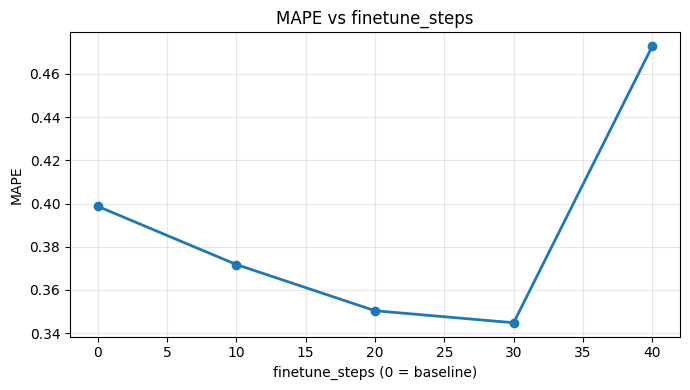

,model,mape,finetune_steps
0,Chronos2-baseline,0.398693,0
1,Chronos2-steps10,0.371732,10
2,Chronos2-steps20,0.350335,20
3,Chronos2-steps30,0.344771,30
4,Chronos2-steps40,0.472876,40


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Build a tidy table with baseline + finetuned variants
mape_table = pd.DataFrame(
    {
        "model": model_cols,
        "mape": [float(avg_mape[m]) for m in model_cols],
    }
)
mape_table["finetune_steps"] = mape_table["model"].map(
    lambda m: 0 if m == "Chronos2-baseline" else int(m.replace("Chronos2-steps", ""))
)
mape_table = mape_table.sort_values("finetune_steps")

# Plot MAPE vs finetuning steps (0 = baseline, no finetuning)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    mape_table["finetune_steps"],
    mape_table["mape"],
    marker="o",
    linewidth=2,
)
ax.set_xlabel("finetune_steps (0 = baseline)")
ax.set_ylabel("MAPE")
ax.set_title("MAPE vs finetune_steps")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mape_table

### Conclusion

Use the plot (and table) to pick the `finetune_steps` value with the **lowest MAPE**; that is the best candidate for this dataset under this backtest setup. In this notebook, `finetune_steps=0` represents the baseline (no finetuning), so you can directly verify whether finetuning improves over baseline.

Because finetuning here runs **on the fly in each cross-validation window**, this result reflects the cost/benefit of repeatedly finetuning before each forecast window.